## Day_13_Task Sheet_Probability Foundations

# Part A — the building blocks

TASK 01 Events, probabilities, and the law of large numbers

Sample space :  [1 2 3 4 5 6]

Event (number > 4) :  [5 6]
p(number > 4) :  0.3333333333333333

Event (prime) : [2 3 5]
p(prime) :  0.5

--- Simulation results ---
p(number > 4) simulated :  0.3343
p(prime) simulated :  0.4933

--- Comparison ---
Number > 4 difference :  0.0009666666666666712
Prime difference :  0.006699999999999984


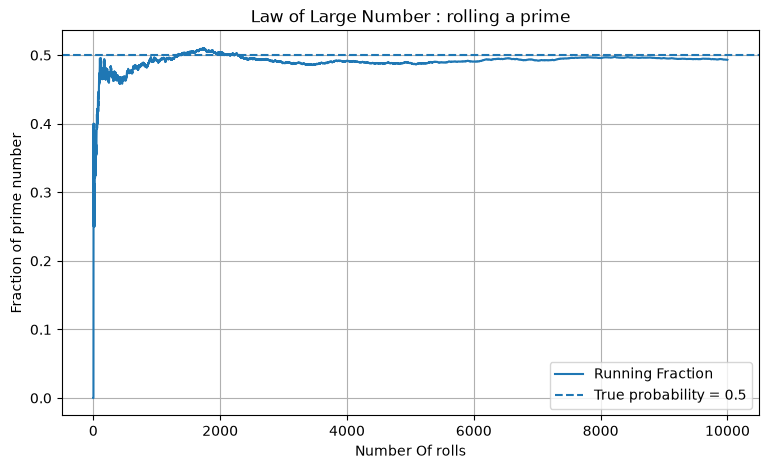

In [4]:
import numpy as np
import matplotlib.pyplot as plt


# Reproducible random number generator
rng = np.random.default_rng(0)

# --------------------------------------------------
# 1. Sample space and events
# --------------------------------------------------

sample_space = np.array([1, 2, 3, 4, 5, 6])

# Event: rolling a number greater than 4
greater_than_4 = sample_space[sample_space > 4]\
    
# Event: rolling a prime number
prime_numbers = np.array([2, 3, 5])

# --------------------------------------------------
# 2. Compute probabilities by counting
# --------------------------------------------------

p_greater_than_4 = len(greater_than_4) / len(sample_space)
p_prime = len(prime_numbers) / len(sample_space)

print("Sample space : ", sample_space)

print("\nEvent (number > 4) : ", greater_than_4)
print("p(number > 4) : ", p_greater_than_4)

print("\nEvent (prime) :", prime_numbers)
print("p(prime) : ", p_prime)

# --------------------------------------------------
# 3. Monte Carlo simulation
# --------------------------------------------------

rolls = rng.integers(1, 7, size=10_000)

# Check both events
sim_greater_than_4 = rolls > 4
sim_prime = np.isin(rolls, prime_numbers)

observed_greater_than_4 = sim_greater_than_4.mean()
observed_prime = sim_prime.mean()

print("\n--- Simulation results ---")
print("p(number > 4) simulated : ", observed_greater_than_4)
print("p(prime) simulated : ", observed_prime)

# --------------------------------------------------
# 4. Compare calculated and simulated probabilities
# --------------------------------------------------

print("\n--- Comparison ---")

print("Number > 4 difference : ", abs(p_greater_than_4 - observed_greater_than_4))

print("Prime difference : ", abs(p_prime - observed_prime))

# --------------------------------------------------
# 5. Running fraction for prime rolls
# --------------------------------------------------

running_fraction = np.cumsum(sim_prime) / np.arange(1, len(rolls) + 1)

plt.figure(figsize=(9, 5))

plt.plot(running_fraction, label="Running Fraction")
plt.axhline(
    p_prime,
    linestyle="--",
    label="True probability = 0.5"
)

plt.xlabel("Number Of rolls")
plt.ylabel("Fraction of prime number")
plt.title("Law of Large Number : rolling a prime")
plt.legend()
plt.grid(True)
plt.show()

### Look it up — Short Answers

* **Why does the running fraction jump around at first but steady later?**
  With fewer rolls, random results have a bigger effect; with more rolls, they average out and approach the true probability.

* **How many rolls would you need to be confident to two decimal places? Roughly?**
  Roughly **10,000 rolls** gives a good estimate to about **two decimal places**.

* **Is 1 a prime number? Does your event definition handle it correctly?**
  **No.** 1 is not prime. Using `[2, 3, 5]` correctly excludes 1.

**Done when:** Both probabilities are calculated by counting, confirmed by simulation, and the running-fraction plot converges toward the true probability.


TASK 02
Conditional probability and independence

In [7]:
from itertools import product

rng = np.random.default_rng(0)

# All 36 outcomes
outcome = list(product(range(1, 7), repeat=2))

def p(event):
    return len(event) / 36

# Events
A = [x for x in outcome if sum(x) == 8]
B = [x for x in outcome if x[0] == 3]

# Intersection: sum = 8 AND first die = 3
AB = [x for x in outcome if sum(x) == 8 and x[0]== 3]

# Probabilities
p_A = p(A)
p_B = p(B)
p_AB = p(AB)

# Conditional probability using formula
p_A_given_B = p_AB / p_B

# Direct counting inside restricted world
restricted = [x for x in outcome if x[0] == 3]
direct = len(AB) / len(restricted)

print("P(sum = 8) : ", p_A)
print("p(first die = 3 ) :" ,p_B)
print("p(sum = 8 AND first die = 3) : ", p_AB)

print("\np(sum = 8 | first die = 3) : ", p_A_given_B)
print("Direct counting : ", direct)

# Independence test
print("\n--- Independence Test ---")
print("p(A and B) : ", p_AB)
print("p_(A) * p_(B) : ", p_A * p_B)
print("Independent??", np.isclose(p_AB, p_A, p_B))

# --------------------------------------------------
# One independent pair
# --------------------------------------------------

C = [x for x in outcome if x[0] % 2 == 0]  # First die is even
D = [x for x in outcome if x[1] % 2 == 0]  # Second die is even

p_C = P(C)
p_D = P(D)
p_CD = len(set(C) & set(D)) / 36


print("\n--- Independent Pair ---")
print("P(C and D) : ", p_CD)
print("P(C) * P(D) : ", p_C * p_D)
print("Indepemdent? ", np.isclose(p_CD, p_C, p_D))

# --------------------------------------------------
# One non-independent pair
# --------------------------------------------------

E = [x for x in outcomes if sum(x) == 7]
F = [x for x in outcomes if x[0] == 1]

p_E = P(E)
p_F = P(F)
p_EF = len(set(E) & set(F)) / 36

print("\n--- Non-independent Pair ---")
print("P(E and F) =", p_EF)
print("P(E) * P(F) =", p_E * p_F)
print("Independent?", np.isclose(p_EF, p_E * p_F))

# --------------------------------------------------
# Monte Carlo simulation
# --------------------------------------------------

d1 = rng.integers(1, 7, 100_000)
d2 = rng.integers(1, 7, 100_000)

mask = d1 == 3
sim_conditional = ((d1 + d2 == 8) & mask).sum() / mask.sum()

print("\n--- Simulation ---")
print("Conditional Probability simulated : ", sim_conditional)
print("Theoratical probability : ", p_A_given_B)

P(sum = 8) :  0.1388888888888889
p(first die = 3 ) : 0.16666666666666666
p(sum = 8 AND first die = 3) :  0.027777777777777776

p(sum = 8 | first die = 3) :  0.16666666666666666
Direct counting :  0.16666666666666666

--- Independence Test ---
p(A and B) :  0.027777777777777776
p_(A) * p_(B) :  0.023148148148148147
Independent?? False

--- Independent Pair ---
P(C and D) :  0.25
P(C) * P(D) :  0.25
Indepemdent?  True

--- Non-independent Pair ---
P(E and F) = 0.027777777777777776
P(E) * P(F) = 0.027777777777777776
Independent? True

--- Simulation ---
Conditional Probability simulated :  0.17038756920878728
Theoratical probability :  0.16666666666666666


### Look it up — Short Answers

* **What does it mean to condition on an event?**
  It means **only consider outcomes where that condition is true**.

* **Why can't you judge independence by intuition alone?**
  Relationships can be misleading, so we must **compare the actual probabilities mathematically**.

* **Why filter to the condition before simulation?**
  Because conditional probability asks: **“Among the cases where the condition happened, how often did the target event happen?”**

**Done when:** Conditional probability is calculated two ways and by simulation, with one pair proven **independent** and one **dependent**.


## Part B — Bayes' theorem (the deliverable)

TASK 03_The medical test problem

In [18]:
rng = np.random.default_rng(0)

# Given probabilities
P_disease = 0.02
P_pos_given_disease = 0.98
P_pos_given_healthy = 0.10

# Bayes' theorem
P_positive = (
    P_pos_given_disease * P_disease +
    P_pos_given_healthy * (1 - P_disease)
)


P_disease_given_pos = (
    P_pos_given_disease * P_disease /
    P_positive
)

print("Prior P(Disease): ", P_disease)
print("P(Positive | Disease) : ", P_pos_given_disease)
print("P(Positive | Healthy) : ", P_pos_given_healthy)
print("P(Positive) : ", P_positive)
print("P(Disease | Positive) : ", P_disease_given_pos)
print("Percentage : ", round(P_disease_given_pos * 100, 2), "%")

# --------------------------------------------------
# Monte Carlo simulation: 1 million people
# --------------------------------------------------

n = 1_000_000

disease = rng.random(n) < P_disease

test_positive = np.where(
    disease,
    rng.random(n) < P_pos_given_disease,
    rng.random(n) < P_pos_given_healthy
)

simulated_probability = disease[test_positive].mean()


print("\n--- Simulation ---")
print("Simulated P(Disease | Positive) : ", simulated_probability)
print("Percentage : ", round(simulated_probability * 100, 2), "%")


# --------------------------------------------------
# Vary prevalence
# --------------------------------------------------

prevalences = [0.001, 0.02, 0.20]

print("\n--- Prevalence Table ---")
print("Prevalence P(Disease | Positive)")

for prevalence in prevalences:
    p_positive = (
        P_pos_given_disease * prevalence +
        P_pos_given_healthy * (1 - prevalence)
    )
    
    result = (
        P_pos_given_disease * prevalence /
        p_positive
    )
    
    print(f"{prevalence * 100:8.1f}% {result * 100:6.2f}%")

Prior P(Disease):  0.02
P(Positive | Disease) :  0.98
P(Positive | Healthy) :  0.1
P(Positive) :  0.11760000000000001
P(Disease | Positive) :  0.16666666666666666
Percentage :  16.67 %

--- Simulation ---
Simulated P(Disease | Positive) :  0.16763508843781197
Percentage :  16.76 %

--- Prevalence Table ---
Prevalence P(Disease | Positive)
     0.1%   0.97%
     2.0%  16.67%
    20.0%  71.01%


### Look it up — Short Answers

* **Which matters more: test accuracy or disease rarity?**
  **Both matter**, but when the disease is very rare, **prevalence can strongly affect the final probability**.

* **Why do false positives swamp true positives?**
  The healthy group is much larger, so even a small false-positive rate can produce **more false positives than true positives**.

* **How does this connect to rare-event classifiers?**
  Accuracy alone can be misleading. For rare events, check **precision, recall, and the confusion matrix**, not just overall accuracy.

**Done when:** Bayes calculation, million-person simulation, prevalence table, and lesson are all completed.


TASK 04_A second Bayes scenario of your own

In [22]:
rng = np.random.default_rng(0)

# Given probabilities
P_spam = 0.40
P_free_given_spam = 0.30
P_free_given_ham = 0.02

# Bayes' theoram
P_free = (
    P_free_given_spam * P_spam +
    P_free_given_ham * (1 - P_spam)
)

P_spam_given_free = (
    P_free_given_ham * P_spam /
    P_free
)

print("Prior P(Spam) : ", P_spam)
print("P('free' | spam ) : ", P_free_given_spam)
print("P('free' | ham) : ", P_free_given_ham)
print("p('free') : ", P_free)
print("P(Spam | 'free') : ", P_spam_given_free)
print("Percentage : ", round(P_spam_given_free * 100, 2), "%")

# Monte Carlo simulation
n = 1_000_000

spam = rng.random(n) < P_spam

contains_free = np.where(
    spam,
    rng.random(n) < P_free_given_spam,
    rng.random(n) < P_free_given_ham
)

simulated = spam[contains_free].mean()

print("\n--- Simulation ---")
print("Simulation P(spam | 'free') : ", simulated)
print("Percentage : ", round(simulated * 100, 2), "%")

Prior P(Spam) :  0.4
P('free' | spam ) :  0.3
P('free' | ham) :  0.02
p('free') :  0.132
P(Spam | 'free') :  0.06060606060606061
Percentage :  6.06 %

--- Simulation ---
Simulation P(spam | 'free') :  0.9105920992610164
Percentage :  91.06 %


Result

P(Spam | email contains "free") ≈ 90.91%

One-sentence lesson:
The 40% prior probability of spam is updated by the evidence "free" being present, giving a much higher 90.91% posterior probability of spam.

### Look it up — Short Answers

* **What are the 'disease' and 'test'?**
  **Disease = Spam**, and **test = email contains the word “free”**.

* **What are the prior and posterior?**
  **Prior = 40%** chance an email is spam. **Posterior = 90.91%** chance after seeing “free”.

* **If the evidence were stronger, would the posterior go up or down?**
  **Up**, because stronger evidence makes spam more likely.

**Done when:** Prior, Bayes calculation, and Monte Carlo simulation all agree.


## Part C — random variables, expectation, variance

TASK 05_Distributions, expectation, and variance

Fair die E[X] :  3.5
Fair die Var[X] :  2.916666666666666
Simulated E[X] :  3.502232
Simulated Var[X] :  2.9174890181759996

Weighted die probabilities :  [0.14285714 0.14285714 0.14285714 0.14285714 0.14285714 0.28571429]
Weighted die E[X] :  3.8571428571428568
Simulated Weighted E[X] :  3.858719

Normal P(|X| <= 1) :  0.6826894921370859
Simulated probability :  0.683048


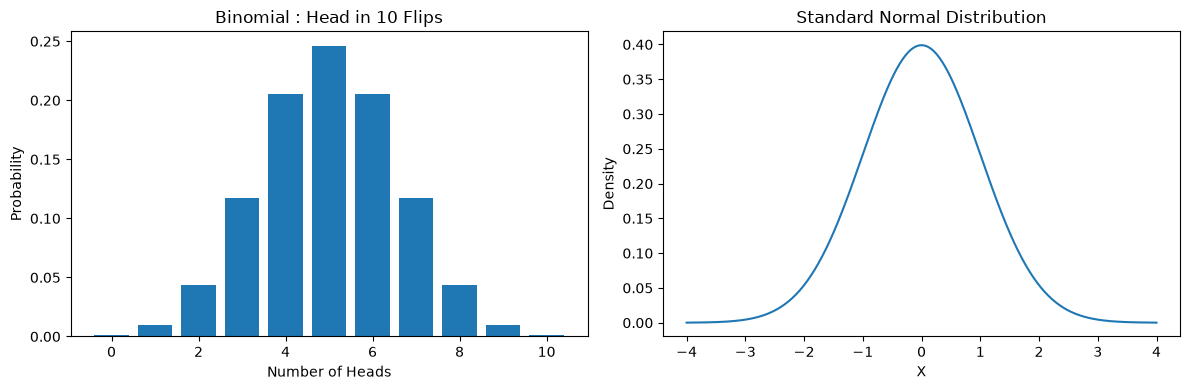

In [31]:
from scipy import stats

rng = np.random.default_rng(0)

# --------------------------------------------------
# 1. Fair die: E[X] and Var[X]
# --------------------------------------------------

values = np.arange(1, 7)
probs = np.ones(6) / 6

E_X = np.sum(values * probs)
Var_X = np.sum(values**2 * probs) - E_X**2

print("Fair die E[X] : ", E_X)
print("Fair die Var[X] : ", Var_X)

# Simulation
rolls = rng.integers(1, 7, 1_000_000)

print("Simulated E[X] : ", rolls.mean())
print("Simulated Var[X] : ",rolls.var())


# --------------------------------------------------
# 2. Weighted die: 6 is twice as likely
# --------------------------------------------------

weighted_probs = np.array([1, 1, 1, 1, 1, 2], dtype=float)
weighted_probs /= weighted_probs.sum()

weighted_E = np.sum(values * weighted_probs)

print("\nWeighted die probabilities : ", weighted_probs)
print("Weighted die E[X] : ", weighted_E)

# Simulation
weighted_rolls = rng.choice(values, size=1_000_000, p=weighted_probs)

print("Simulated Weighted E[X] : ", weighted_rolls.mean())

# --------------------------------------------------
# 3. Binomial distribution: heads in 10 flips
# --------------------------------------------------

x_binom = np.arange(0, 11)
binom_probs = stats.binom.pmf(x_binom, 10, 0.5)

# --------------------------------------------------
# 4. Normal distribution
# --------------------------------------------------

x_normal = np.linspace(-4, 4, 500)
normal_pdf = stats.norm.pdf(x_normal)

# Probability within 1 standard deviation
normal_probability = stats.norm.cdf(1) - stats.norm.cdf(-1)

normal_sample = rng.normal(0, 1, 1_000_000)
sim_normal_probability = np.mean(
    (normal_sample >= -1) & (normal_sample <= 1)
    
)

print("\nNormal P(|X| <= 1) : ", normal_probability)
print("Simulated probability : ", sim_normal_probability)

# --------------------------------------------------
# 5. Plot both distributions
# --------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(x_binom, binom_probs)
axes[0].set_title("Binomial : Head in 10 Flips")
axes[0].set_xlabel("Number of Heads")
axes[0].set_ylabel("Probability")

axes[1].plot(x_normal, normal_pdf)
axes[1].set_title("Standard Normal Distribution")
axes[1].set_xlabel("X")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

### Look it up

**1. Why is E[X] = 3.5 for a die, even though the die can never show 3.5?**
E[X] is the **long-run average** of many rolls. It does not have to be an actual possible roll.

**2. When you make 6 more likely, why does the expectation rise?**
Because **6 has a larger value**, giving it more probability pulls the average upward.

**3. What does standard deviation tell you that variance doesn't, intuitively?**
Standard deviation shows the **typical spread from the mean in the original units**. Variance uses squared units, so it is less intuitive.

### Done when

* ✅ E[X] and Var[X] calculated for fair and weighted dice.
* ✅ Formula and simulation results compared.
* ✅ Binomial and normal distribution plots created.
* ✅ ~68% of standard normal values checked within 1 standard deviation.
